# TCGA-BRCA Multimodal Stratification — 03 · Stratify & Survival

Discover patient subgroups from the integrated matrix, then test whether they matter clinically.

1. **Cluster** the patients with HDBSCAN — on the **integrated PCA space**, not on the 2D map
2. **Visualise** with a 2D UMAP (for the figure only), coloured by cluster and by PAM50
3. **Validate clinically** — Kaplan–Meier survival per cluster + log-rank test
4. **Validate biologically** — overlap between discovered clusters and PAM50 subtypes

Input: `data/processed/integrated.csv`, `data/processed/metadata.csv` (from notebook 02).

In [2]:
pip install lifelines


  Using cached lifelines-0.30.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached autograd-1.8.0-py3-none-any.whl.metadata (7.5 kB)
  Using cached autograd-gamma-0.5.0.tar.gz (4.0 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached lifelines-0.30.3-py3-none-any.whl (409 kB)
Using cached autograd-1.8.0-py3-none-any.whl (51 kB)
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4119 sha256=0285f135f46ba54a040f7e4a291341b4d1949dcf8c9fd6a7ca67fd1c5d8a9aa5
  Stored in directory: /Users/giuliaam/Library/Caches/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [lifelines]/6 [lifelines]
Note: you may need to restart the kernel to use updated packages.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import umap
import hdbscan
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

PROC_DIR = Path("data/processed")
FIG_DIR  = Path("outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# OS_time is in DAYS (we saw range 0–7125); convert to months for readable curves
DAYS_PER_MONTH = 30.44

# HDBSCAN settings — tunable; larger min_cluster_size => fewer, bigger clusters
MIN_CLUSTER_SIZE = 20
MIN_SAMPLES      = 10

PALETTE = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#F4A261",
           "#8338EC", "#3A86FF", "#FB5607"]

integrated = pd.read_csv(PROC_DIR / "integrated.csv", index_col=0)
meta       = pd.read_csv(PROC_DIR / "metadata.csv",   index_col=0)
assert list(integrated.index) == list(meta.index)
print("integrated:", integrated.shape, "| meta:", meta.shape)

integrated: (1078, 100) | meta: (1078, 3)


## 1 · Cluster on the integrated space

We run HDBSCAN directly on the integrated PCA matrix (100 dimensions). This is the deliberate fix versus clustering on a 2D UMAP: the 2D map is a heavily compressed *picture*, and clustering on a picture can invent or merge groups that aren't really there. The PCA space is where the real structure lives, so that's where we cluster.

HDBSCAN is **density-based**: we don't tell it how many clusters to find, and it labels points that don't belong to any dense region as **noise** (`-1`). We report that noise honestly rather than forcing every patient into a group.

In [12]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE,
                            min_samples=MIN_SAMPLES)
labels = clusterer.fit_predict(integrated.values)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = int((labels == -1).sum())
print(f"{n_clusters} clusters, {n_noise} noise points ({n_noise/len(labels):.1%})")
print(pd.Series(labels).value_counts().sort_index())

0 clusters, 1078 noise points (100.0%)
-1    1078
Name: count, dtype: int64


In [13]:
# HDBSCAN is not showing good results in high dimensions, hence we reduce the space to 10D with UMAP
# 2D map is for visulalization purposes only, not for clustering. 
clustering_space = umap.UMAP(n_components=10, n_neighbors=30, min_dist=0.0,
                             random_state=42).fit_transform(integrated.values)

clusterer = hdbscan.HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE,
                            min_samples=MIN_SAMPLES)
labels = clusterer.fit_predict(clustering_space)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = int((labels == -1).sum())
print(f"{n_clusters} clusters, {n_noise} noise points ({n_noise/len(labels):.1%})")
print(pd.Series(labels).value_counts().sort_index())

/opt/anaconda3/envs/unet-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2 clusters, 0 noise points (0.0%)
0    181
1    897
Name: count, dtype: int64


> **If the result looks off** (e.g. 1 giant cluster, or >40% noise), the knobs to turn are `MIN_CLUSTER_SIZE` and `MIN_SAMPLES` at the top. A common alternative is to first reduce the integrated space to ~10 UMAP dimensions and cluster on that — more forgiving for density estimation, at the cost of one less-interpretable step. Keep the simple version unless it misbehaves.

## 2 · Visualise with UMAP (figure only)

UMAP collapses the 100-dim space to 2D *for the human eye*. The clusters were already decided in step 1 — UMAP does not get a vote. We colour the same map two ways: by our HDBSCAN cluster, and by PAM50 subtype (the known biology) as a side-by-side sanity check.

/opt/anaconda3/envs/unet-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


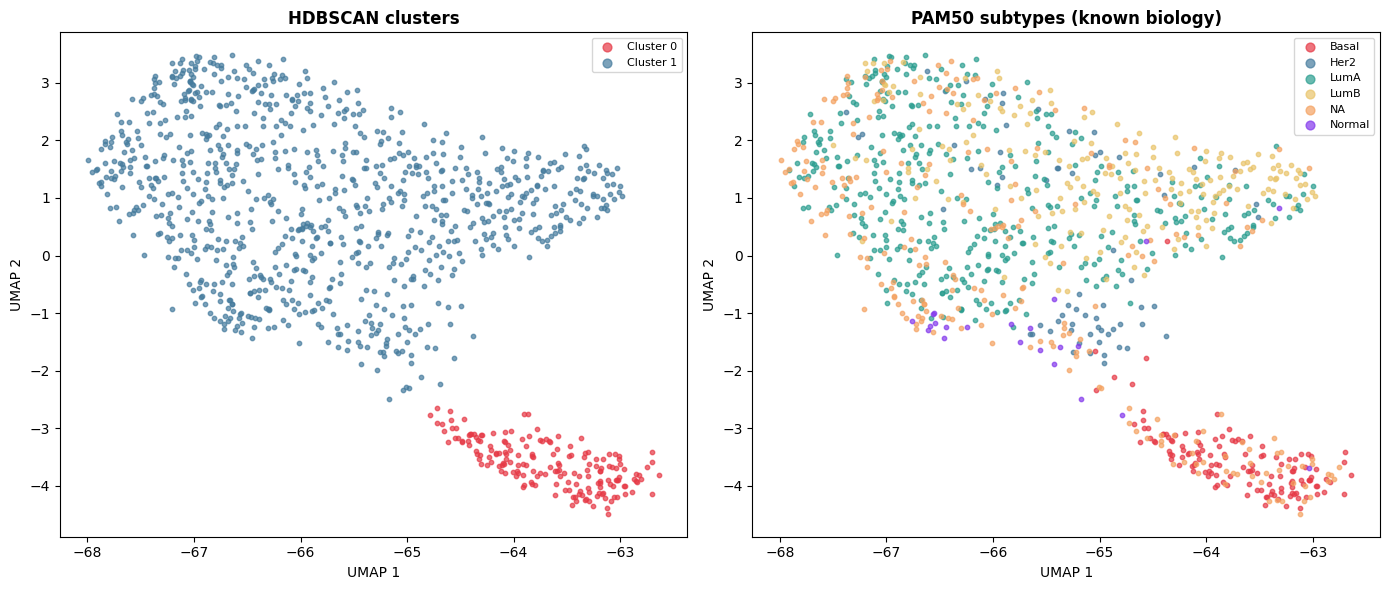

In [14]:
embedding = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                      random_state=42).fit_transform(integrated.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left: HDBSCAN clusters
ax = axes[0]
for i, cl in enumerate(sorted(set(labels))):
    m = labels == cl
    color = "#CCCCCC" if cl == -1 else PALETTE[i % len(PALETTE)]
    name  = "Noise" if cl == -1 else f"Cluster {cl}"
    ax.scatter(embedding[m, 0], embedding[m, 1], c=color, s=10, alpha=0.7, label=name)
ax.set_title("HDBSCAN clusters", fontweight="bold")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2"); ax.legend(markerscale=2, fontsize=8)

# right: PAM50 subtypes
ax = axes[1]
pam = meta["PAM50"].fillna("NA").values
for i, st in enumerate(sorted(set(pam))):
    m = pam == st
    ax.scatter(embedding[m, 0], embedding[m, 1], c=PALETTE[i % len(PALETTE)],
               s=10, alpha=0.7, label=st)
ax.set_title("PAM50 subtypes (known biology)", fontweight="bold")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2"); ax.legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "umap_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

## 3 · Clinical validation — Kaplan–Meier

The real test: do the unsupervised clusters differ in **survival**? For each cluster we draw a Kaplan–Meier curve (probability of surviving over time) and run a **log-rank test** across clusters — its p-value asks "are these survival curves different beyond chance?". Noise points are excluded. Time is converted from days to months for readability.

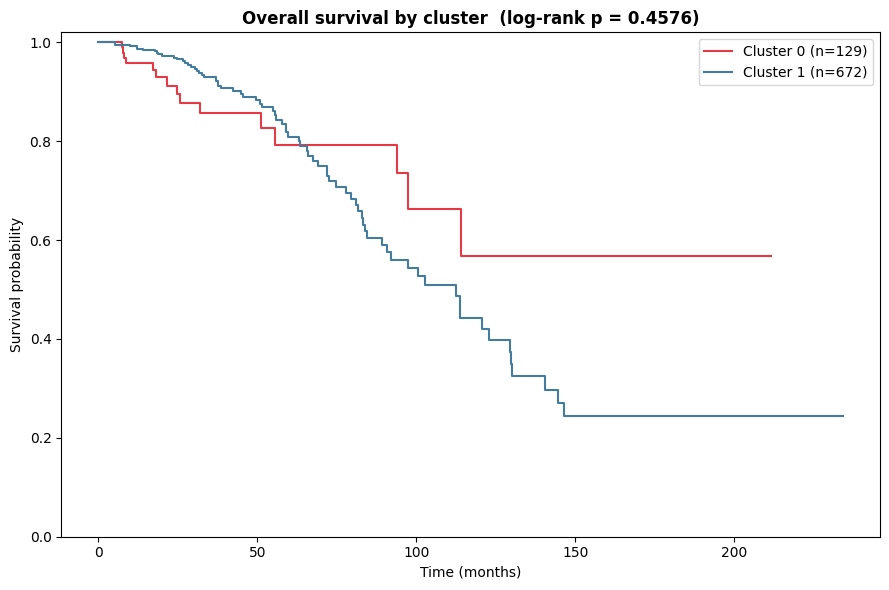

log-rank across clusters: p = 0.4576


In [15]:
surv = meta.copy()
surv["cluster"] = labels
surv = surv[surv["cluster"] != -1].dropna(subset=["OS_time", "OS_event"])
surv["OS_months"] = surv["OS_time"] / DAYS_PER_MONTH

fig, ax = plt.subplots(figsize=(9, 6))
kmf = KaplanMeierFitter()
for i, cl in enumerate(sorted(surv["cluster"].unique())):
    m = surv["cluster"] == cl
    kmf.fit(surv.loc[m, "OS_months"], surv.loc[m, "OS_event"],
            label=f"Cluster {cl} (n={int(m.sum())})")
    kmf.plot_survival_function(ax=ax, ci_show=False, color=PALETTE[i % len(PALETTE)])

res = multivariate_logrank_test(surv["OS_months"], surv["cluster"], surv["OS_event"])
p = res.p_value
p_str = "p < 0.0001" if p < 1e-4 else f"p = {p:.4f}"
ax.set_title(f"Overall survival by cluster  (log-rank {p_str})", fontweight="bold")
ax.set_xlabel("Time (months)"); ax.set_ylabel("Survival probability"); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "kaplan_meier.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"log-rank across clusters: {p_str}")

## 4 · Biological validation — PAM50 overlap

PAM50 is the established molecular classification of breast cancer. If our data-driven clusters recover something biologically real, they should line up — at least partly — with PAM50. We show the PAM50 composition of each cluster (not to grade ourselves against PAM50, but to interpret what each cluster *is*).

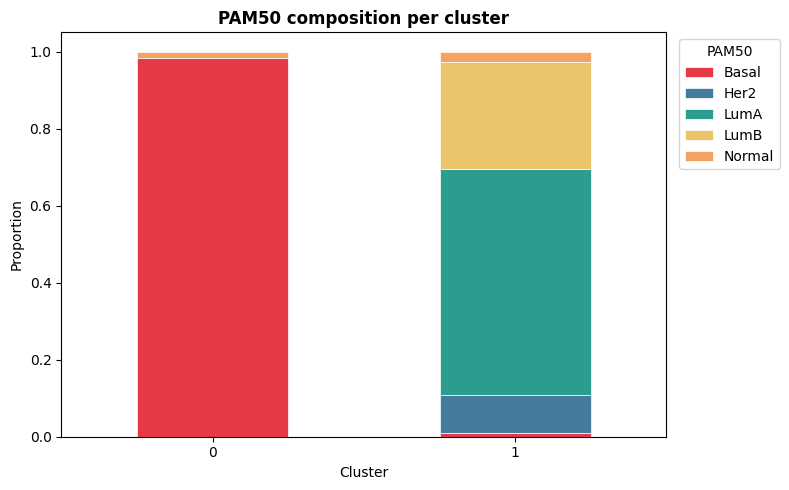

PAM50    Basal  Her2  LumA  LumB  Normal
cluster                                 
0         0.98   0.0  0.00  0.00    0.02
1         0.01   0.1  0.59  0.28    0.03


In [9]:
overlap = pd.crosstab(surv["cluster"], surv["PAM50"], normalize="index")

fig, ax = plt.subplots(figsize=(8, 5))
overlap.plot(kind="bar", stacked=True, ax=ax,
             color=PALETTE[:overlap.shape[1]], edgecolor="white", linewidth=0.5)
ax.set_title("PAM50 composition per cluster", fontweight="bold")
ax.set_xlabel("Cluster"); ax.set_ylabel("Proportion")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="PAM50", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "cluster_pam50_overlap.png", dpi=150, bbox_inches="tight")
plt.show()
print(overlap.round(2))

## 5 · Save results

In [10]:
results = meta.copy()
results["cluster"] = labels
results["UMAP_1"]  = embedding[:, 0]
results["UMAP_2"]  = embedding[:, 1]
results.to_csv(PROC_DIR / "results.csv")
print("saved -> data/processed/results.csv")
print("figures -> outputs/figures/ (umap_clusters, kaplan_meier, cluster_pam50_overlap)")

saved -> data/processed/results.csv
figures -> outputs/figures/ (umap_clusters, kaplan_meier, cluster_pam50_overlap)


## How to read this

- **log-rank p < 0.05** → the clusters separate survival: the stratification carries clinical signal. A non-significant p is still a real (reportable) result, not a failure.
- **PAM50 overlap** → tells you what each cluster is (e.g. a mostly-Basal cluster, a Luminal-A-enriched cluster).
- **noise %** → HDBSCAN's honesty: patients it wouldn't force into a group.
